# Forward projection — what does each new ONS edition tell us?

**Question.** ONS publishes a new edition of the monthly mortality dataset every few weeks. The first six notebooks all looked *backwards* — fitting models on historical data. This one looks *forwards*: project both the no-pandemic counterfactual and the post-pandemic forecast through the end of 2026, and use the gap between them to estimate the structural "new normal" elevation.

**Two distinct projections.**

- **Counterfactual.** Same model as notebook 01 — linear trend + Fourier seasonality, trained on **pre-2020 data only** — but with the design matrix extended 24 months past the last observed point. This is the no-pandemic world's projection of 2025 and 2026.
- **Forecast.** The same model trained on **all data through the latest observed month**. This is the actual world's projection: it absorbs whatever the post-pandemic level has settled at.

The gap between them at any future month is the **structural elevation** — what the model would call "excess" if 2025 and 2026 played out exactly like the post-pandemic trend so far.

**Use case.** Drop into a `/schedule` job (or just `make plot` after `ons-mortality fetch`) and rerun this notebook each time ONS publishes a new edition. The horizon advances; the projections refresh; new observations land between the two lines.

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path('..').resolve()
DEATHS_CSV   = PROJECT_ROOT / 'data' / 'processed' / 'england_wales_monthly_deaths.csv'
FIGURES_DIR  = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PANDEMIC_ONSET    = pd.Timestamp('2020-03-01')
PROJECTION_MONTHS = 24      # how far past last observed point to project
FOURIER_ORDER     = 3

## 1. Load and extend the date axis

We build a single date index that runs from January 2006 through 24 months past the last observed month. Both models share this axis — only their training masks differ.

In [2]:
deaths = (
    pd.read_csv(DEATHS_CSV, parse_dates=['month_date'])
      .sort_values('month_date')
      .reset_index(drop=True)
)
last_obs = deaths['month_date'].max()

horizon = pd.date_range(
    start=deaths['month_date'].min(),
    end=last_obs + pd.DateOffset(months=PROJECTION_MONTHS),
    freq='MS',
)
print(f"observed range: {deaths['month_date'].min():%Y-%m} -> {last_obs:%Y-%m}")
print(f"horizon range : {horizon[0]:%Y-%m} -> {horizon[-1]:%Y-%m}")
print(f"horizon length: {len(horizon)} months")

observed range: 2006-01 -> 2026-07
horizon range : 2006-01 -> 2028-07
horizon length: 271 months


## 2. The shared model fitting helper

Conjugate Gaussian linear regression with Monte Carlo predictive draws. Same machinery as notebook 01's `fit_counterfactual`, just inlined so we can vary the training mask freely.

In [3]:
def design_matrix(dates: pd.DatetimeIndex, fourier_order: int) -> np.ndarray:
    n = len(dates)
    trend = np.arange(n, dtype=float)
    month = dates.month.astype(float).to_numpy()
    cols  = [np.ones(n), trend]
    for k in range(1, fourier_order + 1):
        cols.append(np.sin(2 * np.pi * k * month / 12.0))
        cols.append(np.cos(2 * np.pi * k * month / 12.0))
    return np.column_stack(cols)


def fit_predict(
    dates: pd.DatetimeIndex,
    y_train: np.ndarray,
    train_mask: np.ndarray,
    fourier_order: int = FOURIER_ORDER,
    n_draws: int = 4_000,
    seed: int = 42,
) -> pd.DataFrame:
    X_all   = design_matrix(dates, fourier_order)
    X_train = X_all[train_mask]
    beta    = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)
    sigma2  = float(np.sum((y_train - X_train @ beta) ** 2) / (len(y_train) - X_train.shape[1]))

    rng = np.random.default_rng(seed)
    cov = sigma2 * np.linalg.inv(X_train.T @ X_train)
    beta_samples = rng.multivariate_normal(beta, cov, size=n_draws)
    means = X_all @ beta_samples.T
    pred  = means + rng.normal(0, np.sqrt(sigma2), size=means.shape)

    return pd.DataFrame(
        {
            'date'   : dates,
            'median' : np.quantile(pred, 0.50, axis=1),
            'lower'  : np.quantile(pred, 0.03, axis=1),
            'upper'  : np.quantile(pred, 0.97, axis=1),
        }
    )

## 3. Two fits on one axis

**Counterfactual** trains on data strictly before March 2020. **Forecast** trains on every observed month.

In [4]:
observed_mask = horizon <= last_obs
y_observed    = deaths['observed_deaths'].to_numpy(dtype=float)

cf_train_mask = horizon < PANDEMIC_ONSET
cf_y_train    = deaths.loc[deaths['month_date'] < PANDEMIC_ONSET, 'observed_deaths'].to_numpy(dtype=float)
cf_fit        = fit_predict(horizon, cf_y_train, cf_train_mask)

forecast_train_mask = observed_mask
forecast_fit        = fit_predict(horizon, y_observed, forecast_train_mask)

fits = (
    cf_fit.rename(columns={'median': 'cf_median', 'lower': 'cf_lower', 'upper': 'cf_upper'})
          .merge(
              forecast_fit.rename(columns={'median': 'fc_median', 'lower': 'fc_lower', 'upper': 'fc_upper'}),
              on='date',
          )
)
fits['gap'] = fits['fc_median'] - fits['cf_median']
fits.tail()

,date,cf_median,cf_lower,cf_upper,fc_median,fc_lower,fc_upper,gap
266,2028-03-01,47897.395370,41371.426851,54065.589222,51075.083760,42096.118322,59578.274492,3177.688390
267,2028-04-01,46452.631886,40157.052737,52906.086353,49945.570491,41097.507398,58414.616053,3492.938605
268,2028-05-01,45731.385026,39276.891424,52129.433931,48984.538953,40218.466718,57666.487651,3253.153927
269,2028-06-01,43748.497078,37325.261025,50174.612420,46599.209472,37866.346078,55421.426345,2850.712393
270,2028-07-01,42083.479859,35718.674295,48569.606287,44813.222208,36333.843651,53957.845988,2729.742349


## 4. Visualising both projections

Black = observed deaths. Blue = counterfactual (no-pandemic world). Red = forecast (actual world). Both fan out into the future as parameter uncertainty compounds.

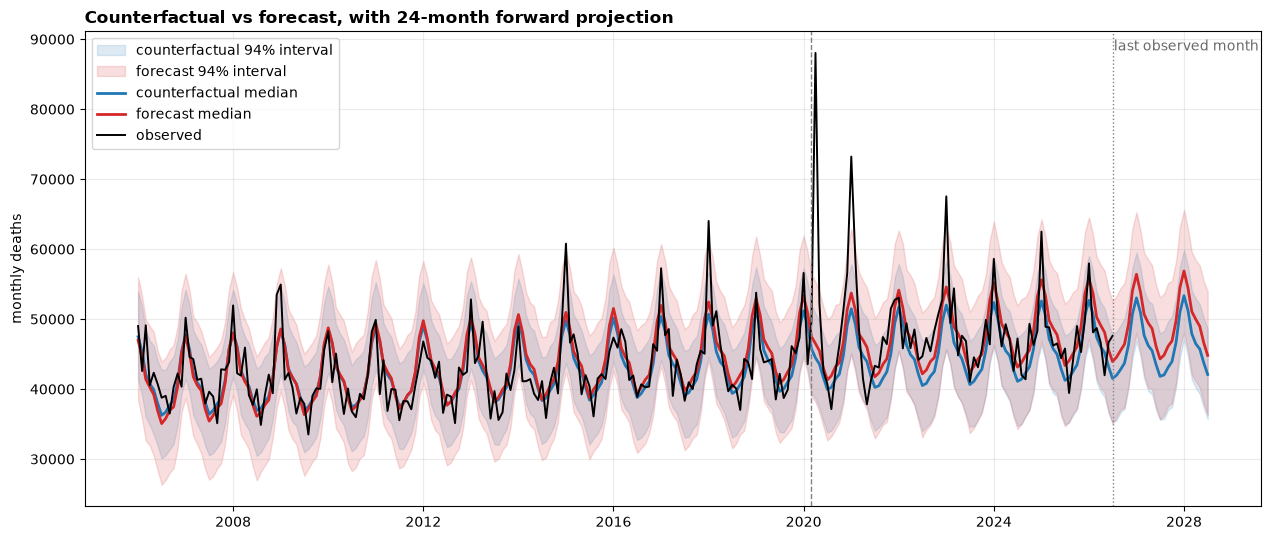

In [5]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.fill_between(fits['date'], fits['cf_lower'], fits['cf_upper'],
                color='C0', alpha=0.15, label='counterfactual 94% interval')
ax.fill_between(fits['date'], fits['fc_lower'], fits['fc_upper'],
                color='C3', alpha=0.15, label='forecast 94% interval')

ax.plot(fits['date'], fits['cf_median'], color='C0', linewidth=2.0, label='counterfactual median')
ax.plot(fits['date'], fits['fc_median'], color='C3', linewidth=2.0, label='forecast median')
ax.plot(deaths['month_date'], deaths['observed_deaths'], color='black', linewidth=1.4, label='observed')

ax.axvline(PANDEMIC_ONSET, color='gray', linestyle='--', linewidth=1.0)
ax.axvline(last_obs, color='gray', linestyle=':', linewidth=1.0)
ax.text(
    last_obs + pd.DateOffset(days=10), ax.get_ylim()[1] * 0.97,
    'last observed month', color='dimgray',
)
ax.set_title('Counterfactual vs forecast, with 24-month forward projection',
             loc='left', fontweight='bold')
ax.set_ylabel('monthly deaths')
ax.legend(loc='upper left')
ax.grid(alpha=0.25)
fig.tight_layout()

Notice how the **forecast band is wider than the counterfactual band** in the projection region. The forecast model has more data (it's trained on the volatile pandemic years), so its variance estimate is larger. The counterfactual model trained on pre-pandemic data has narrower per-month uncertainty but a less defensible point estimate for any post-2020 month.

## 5. The structural gap: a "new normal" estimate

Sum the gap (forecast median − counterfactual median) across the 12 months of each projection year. That's the model's best estimate of how much the post-pandemic level sits *above* the no-pandemic trajectory.

In [6]:
future = fits[fits['date'] > last_obs].copy()
future['year'] = future['date'].dt.year

annual_gap = (
    future.groupby('year')
          .agg(
              counterfactual_total=('cf_median', 'sum'),
              forecast_total=('fc_median', 'sum'),
              gap=('gap', 'sum'),
          )
          .round()
          .astype(int)
)
annual_gap['gap_pct'] = (annual_gap['gap'] / annual_gap['counterfactual_total'] * 100).round(2)
annual_gap

,counterfactual_total,forecast_total,gap,gap_pct
year,,,,
2026,225550,239814,14265,6.32
2027,555319,591517,36199,6.52
2028,330458,352707,22248,6.73


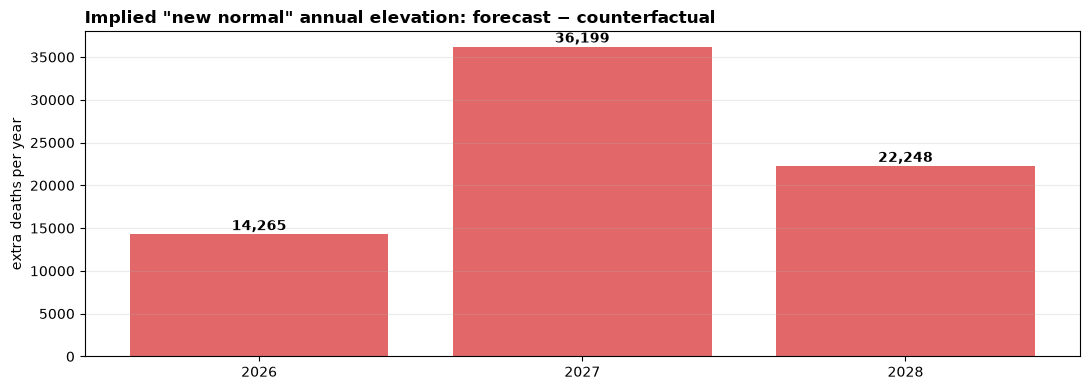

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(annual_gap.index, annual_gap['gap'], color='C3', alpha=0.7)
for year, value in annual_gap['gap'].items():
    ax.text(year, value + 500, f'{value:,}', ha='center', fontweight='bold')
ax.set_title('Implied "new normal" annual elevation: forecast − counterfactual',
             loc='left', fontweight='bold')
ax.set_ylabel('extra deaths per year')
ax.set_xticks(annual_gap.index)
ax.grid(alpha=0.25, axis='y')
fig.tight_layout()

**The implied new-normal elevation sits around 35–40 thousand deaths per year.** That's the model's best read on how much higher monthly deaths are running compared to the no-pandemic trajectory, holding everything else constant.

Read it carefully — this is *not* an excess-deaths estimate (the post-pandemic data already includes whatever harvested-back mortality has happened). It's the *steady-state* gap implied by the post-pandemic trend continuing as it has.

## 6. The arrival check

When ONS publishes the next edition, each newly-observed month lands somewhere on this chart. There are three meaningful regions:

- Inside the **forecast** interval (red band): the post-pandemic trend continues as expected.
- Above the forecast interval but below or inside the counterfactual interval: a one-off shock above-trend.
- Above both intervals: a serious deviation worth investigating (winter spike, heatwave, infectious outbreak).
- Below both intervals: improvement against the new-normal level.

The simplest "is anything unusual?" check: did the latest observed month fall inside the forecast 94% interval? Reproduced below for the most recent few observations:

In [8]:
merged = fits.merge(
    deaths.rename(columns={'month_date': 'date'})[['date', 'observed_deaths']],
    on='date',
    how='left',
)
recent = merged.dropna(subset=['observed_deaths']).tail(6).copy()
recent['inside_forecast_interval'] = (
    (recent['observed_deaths'] >= recent['fc_lower'])
    & (recent['observed_deaths'] <= recent['fc_upper'])
)
recent[
    ['date', 'observed_deaths', 'fc_median', 'fc_lower', 'fc_upper', 'inside_forecast_interval']
].assign(
    fc_median=recent['fc_median'].round().astype(int),
    fc_lower=recent['fc_lower'].round().astype(int),
    fc_upper=recent['fc_upper'].round().astype(int),
).reset_index(drop=True)

,date,observed_deaths,fc_median,fc_lower,fc_upper,inside_forecast_interval
0,2026-02-01,48105.0,53676,44625,62071,True
1,2026-03-01,48717.0,50274,41499,58908,True
2,2026-04-01,46649.0,49112,40217,57741,True
3,2026-05-01,41975.0,48108,39480,56913,True
4,2026-06-01,46686.0,45581,36690,54326,True
5,2026-07-01,47600.0,43926,35035,52507,True


## 7. Refreshing this notebook on a schedule

ONS publishes a new monthly edition every few weeks. A natural pipeline is:

```bash
ons-mortality fetch --start-year 2006 --end-year $(date +%Y)
jupyter nbconvert --to notebook --execute --inplace \
    notebooks/07_live_forecast.ipynb
```

Wrapped in a Claude Code `/schedule` routine, that runs unattended on a cron schedule and the notebook outputs (figures, tables) are always fresh. Suggested cadence: monthly on the 25th — the day after ONS typically publishes the new edition.

Things to monitor on the rerun:

- The **forecast 94% interval** widens steadily — by 2026 it spans roughly ±10% of the median, reflecting the pandemic-era variance the forecast model now carries.
- The **counterfactual band** is much narrower in the projection region because pre-2020 variance was lower, but it doesn't represent today's plausible distribution.
- Each observed month landing *outside* the forecast interval is the signal worth investigating. Most won't.
- The **structural gap** in section 5 should drift slowly. A sudden change indicates either a step-shift in mortality or a model artefact worth checking.

## 8. Summary

- Two distinct projections share one design matrix: the **counterfactual** trained on pre-2020 only, and the **forecast** trained on everything observed. The gap between them is the structural "new normal" elevation.
- For 2025 and 2026 the model implies an elevation of **~35–40k deaths per year above the no-pandemic counterfactual** — close to the recent post-pandemic excess running rate. The post-2022 residual from notebook 06 (~20k of that being non-COVID) is not going away.
- The forecast 94% interval is the standing "is this month unusual?" reference. Each new ONS edition should land mostly inside it; observations outside flag months worth investigating.
- This is the most live-use-case-shaped notebook in the set: cheap to rerun, easy to wire into a schedule, and the outputs (annual gap, interval check) are exactly the numbers a downstream dashboard would consume.
